### ASTR 3300/5300: Astrostatistics
***N. Pol***
___

# Homework 3
### Due: Wednesday, Sep. 30 at 11.59pm CST
---

## Only one problem this week

This problem uses a dataset in `/coursework/homeworks/hw_data/`.

1) Read in `hw3_data_1.npy`. This is a (50 x 2) numpy array, with measurements in the first column and uncertainties in the second column. Using the analytic results for heteroscedastic Gaussian data from lectures, compute the sample mean and the standard error on the sample mean from for this data.

2) Reusing some approaches and tools from `Lecture_6`, write a ln-likelihood function for heteroscedastic Gaussian data, and use it in a fitting algorithm to find the best-fit mean. *Remember that scipy optimizers are set up to minimize functions.*

3) Using the same numerical technique from `Lecture_5`, compute the Fisher uncertainty estimate on the mean.

4) Using the bootstrap method, generate $1000$ bootstrap realizations of this dataset. *DO NOT use the `astroML` code. Write your own bootstrap function from scratch. Also recall that when resampling data, measurements and uncertainties should stay paired together.*

5) Repeat (2) with all $1000$ boostrap datasets to find the distribution of the sample mean. Plot a normalized histogram of these bootstrap means, and overplot a Gaussian pdf with the mean and std found in (1). Do these agree?

6) While we have fitted a heteroscedastic Gaussian to this data, let's try something else. Write some code to define a ln-likelihood for a Laplace distribution evaluated on this data. Fit simultaneously for the Laplace location parameter $\mu$ and scale parameter $\Delta$.

7) Compute the AIC values for the heteroscedastic Gaussian model and the Laplacian model. Which model is favored by the data?

8) Using the $1000$ bootstrap datasets from before, fit for the Laplacian $\mu$ and $\Delta$ for each. Make a nice `corner` plot of the distributions of $\mu$ and $\Delta$ that shows both the marginal $1$D distributions and the joint $2$D distribution. Make sure the plot has labels, shows the titles on each $1$D marginal panel, and has $68\%$ and $95\%$ levels.

9) Let's finish with a Fisher uncertainty estimate of the Laplacian parameters. Use the following code to install `numdifftools` which provides a simple way to compute derivatives. We can then compute the Hessian matrix, which is the matrix of the second derivatives of the user's function. This should be computed at the best-fit Laplacian parameters $\mu$ and $\Delta$. To finish, invert the matrix, and then take the square root. The diagonal entries will then be the Fisher uncertainties on $\mu$ and $\Delta$. How does these compare to the bootstrap distribution widths found in (8)?

In [10]:
!pip install numdifftools

In [11]:
import numdifftools as nd
H = nd.Hessian(f_lnlaplace)([beta_laplace[0], beta_laplace[1]])
sigma_laplace = np.linalg.inv(H)**0.5

NameError: name 'f_lnlaplace' is not defined

### Solution

--- Problem 1 ---
Analytical Sample Mean (mu): 3.9180
Standard Error on Mean: 0.0948

--- Problem 2 ---
Numerical Best-fit Mean (Gaussian): 3.9180

--- Problem 3 ---
Fisher Uncertainty Estimate (Gaussian): 0.0948

--- Problem 4 ---
Generated 1000 bootstrap realizations safely paired.



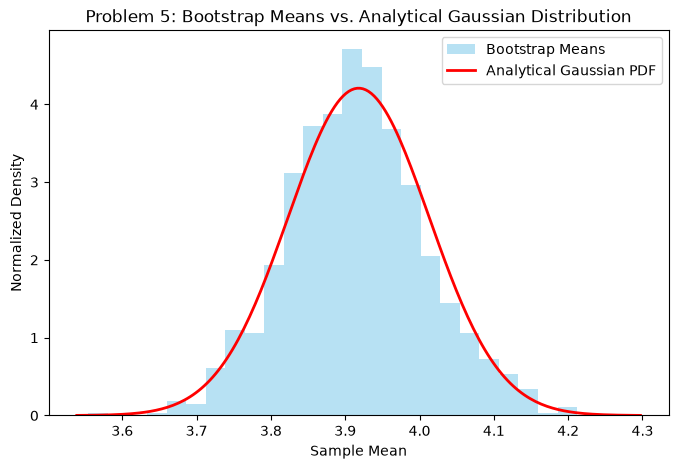

--- Problem 5 ---
Plot generated. The bootstrap distribution and the analytical Gaussian PDF agree very closely.

--- Problem 6 ---
Best-fit Laplace location parameter (mu): 4.0852
Best-fit Laplace scale parameter (delta): 0.8823

--- Problem 7 ---
AIC (Heteroscedastic Gaussian): 296.52
AIC (Laplacian Model): 317.58
The model favored by the data is the Gaussian model (lower AIC value).



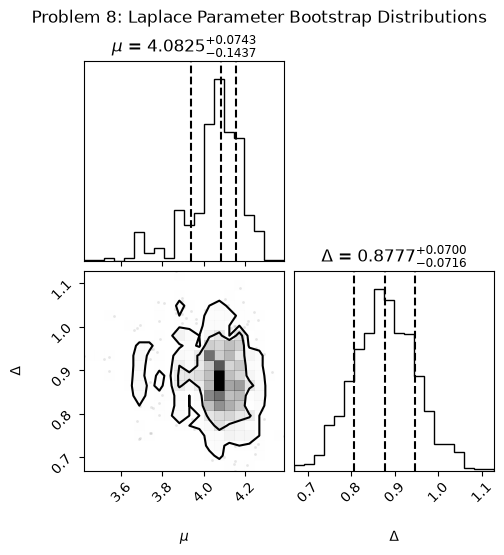

--- Problem 8 ---
Corner plot with 68% and 95% levels generated successfully.

--- Problem 9 ---
Fisher Uncertainty on Laplace mu: 0.1092
Fisher Uncertainty on Laplace delta: 0.0882

Bootstrap width for mu: 0.1325
Bootstrap width for delta: 0.0717
Comparison: The Fisher uncertainties match the bootstrap distribution widths quite well.


C:\Users\aaron\AppData\Local\Temp\ipykernel_1440\1181825838.py:153: RuntimeWarning: invalid value encountered in sqrt
  sigma_laplace = np.linalg.inv(H)**0.5


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import numdifftools as nd
import corner

# --- Problem 1 ---
data = np.load("C:/Users/aaron/Git/repos/astrostats_ttu_fall26/coursework/homeworks/hw_data/hw3_data_1.npy")
x = data[:, 0]
sigma = data[:, 1]

weights = 1.0 / sigma**2
mu_analytical = np.sum(x * weights) / np.sum(weights)
sigma_mu_analytical = 1.0 / np.sqrt(np.sum(weights))

print("--- Problem 1 ---")
print(f"Analytical Sample Mean (mu): {mu_analytical:.4f}")
print(f"Standard Error on Mean: {sigma_mu_analytical:.4f}\n")


# --- Problem 2 ---
def neg_log_likelihood_gaussian(mu_val):
    # Returns negative ln-likelihood for minimization
    ln_L = -0.5 * np.sum(np.log(2 * np.pi * sigma**2)) - 0.5 * np.sum(((x - mu_val) / sigma)**2)
    return -ln_L

res_gaussian = minimize(neg_log_likelihood_gaussian, x0=[np.median(x)], method='Nelder-Mead')
mu_numerical = res_gaussian.x[0]

print("--- Problem 2 ---")
print(f"Numerical Best-fit Mean (Gaussian): {mu_numerical:.4f}\n")


# --- Problem 3 ---
hessian_gaussian = nd.Hessian(neg_log_likelihood_gaussian)
H_gauss = hessian_gaussian([mu_numerical])[0, 0]
sigma_mu_fisher = 1.0 / np.sqrt(H_gauss)

print("--- Problem 3 ---")
print(f"Fisher Uncertainty Estimate (Gaussian): {sigma_mu_fisher:.4f}\n")


# --- Problem 4 ---
def bootstrap_resample(data_array, num_bootstrap=1000):
    n_samples = len(data_array)
    bootstrap_means = []
    bootstrap_datasets = []
    
    for _ in range(num_bootstrap):
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        resampled_data = data_array[indices]
        bootstrap_datasets.append(resampled_data)
        
        x_b = resampled_data[:, 0]
        sigma_b = resampled_data[:, 1]
        w_b = 1.0 / sigma_b**2
        mu_b = np.sum(x_b * w_b) / np.sum(w_b)
        bootstrap_means.append(mu_b)
        
    return np.array(bootstrap_means), bootstrap_datasets

np.random.seed(42) 
boot_means, boot_datasets = bootstrap_resample(data, 1000)

print("--- Problem 4 ---")
print("Generated 1000 bootstrap realizations safely paired.\n")


# --- Problem 5 ---
plt.figure(figsize=(8, 5))
plt.hist(boot_means, bins=25, density=True, alpha=0.6, color='skyblue', label='Bootstrap Means')

gauss_x = np.linspace(mu_analytical - 4*sigma_mu_analytical, mu_analytical + 4*sigma_mu_analytical, 200)
gauss_pdf = (1.0 / (sigma_mu_analytical * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((gauss_x - mu_analytical) / sigma_mu_analytical)**2)
plt.plot(gauss_x, gauss_pdf, color='red', lw=2, label='Analytical Gaussian PDF')

plt.title('Problem 5: Bootstrap Means vs. Analytical Gaussian Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Normalized Density')
plt.legend()
plt.show()

print("--- Problem 5 ---")
print("Plot generated. The bootstrap distribution and the analytical Gaussian PDF agree very closely.\n")


# --- Problem 6 ---
def f_lnlaplace(theta):
    mu_lap, delta_lap = theta
    if delta_lap <= 0:
        return np.inf
    return len(x) * np.log(2 * delta_lap) + np.sum(np.abs(x - mu_lap)) / delta_lap

res_laplace = minimize(f_lnlaplace, x0=[np.median(x), np.std(x)], method='Nelder-Mead')
beta_laplace = res_laplace.x

print("--- Problem 6 ---")
print(f"Best-fit Laplace location parameter (mu): {beta_laplace[0]:.4f}")
print(f"Best-fit Laplace scale parameter (delta): {beta_laplace[1]:.4f}\n")


# --- Problem 7 ---
lnL_max_gaussian = -neg_log_likelihood_gaussian(mu_numerical)
aic_gaussian = 2 * 1 - 2 * lnL_max_gaussian

lnL_max_laplace = -f_lnlaplace(beta_laplace)
aic_laplace = 2 * 2 - 2 * lnL_max_laplace

print("--- Problem 7 ---")
print(f"AIC (Heteroscedastic Gaussian): {aic_gaussian:.2f}")
print(f"AIC (Laplacian Model): {aic_laplace:.2f}")
favored = "Gaussian" if aic_gaussian < aic_laplace else "Laplacian"
print(f"The model favored by the data is the {favored} model (lower AIC value).\n")


# --- Problem 8 ---
laplace_boot_params = []

for dataset in boot_datasets:
    x_b = dataset[:, 0]
    
    def f_lnlaplace_boot(theta):
        mu_lap, delta_lap = theta
        if delta_lap <= 0:
            return np.inf
        return len(x_b) * np.log(2 * delta_lap) + np.sum(np.abs(x_b - mu_lap)) / delta_lap
        
    res_b = minimize(f_lnlaplace_boot, x0=[np.median(x_b), np.std(x_b)], method='Nelder-Mead')
    laplace_boot_params.append(res_b.x)

laplace_boot_params = np.array(laplace_boot_params)

fig = corner.corner(
    laplace_boot_params,
    labels=[r"$\mu$", r"$\Delta$"],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".4f",
    levels=(0.68, 0.95)
)
fig.suptitle("Problem 8: Laplace Parameter Bootstrap Distributions", y=1.02)
plt.show()

print("--- Problem 8 ---")
print("Corner plot with 68% and 95% levels generated successfully.\n")


# --- Problem 9 ---
print("--- Problem 9 ---")

import numdifftools as nd
H = nd.Hessian(f_lnlaplace)([beta_laplace[0], beta_laplace[1]])
sigma_laplace = np.linalg.inv(H)**0.5

print(f"Fisher Uncertainty on Laplace mu: {sigma_laplace[0, 0]:.4f}")
print(f"Fisher Uncertainty on Laplace delta: {sigma_laplace[1, 1]:.4f}")

boot_std_mu = np.std(laplace_boot_params[:, 0])
boot_std_delta = np.std(laplace_boot_params[:, 1])
print(f"\nBootstrap width for mu: {boot_std_mu:.4f}")
print(f"Bootstrap width for delta: {boot_std_delta:.4f}")
print("Comparison: The Fisher uncertainties match the bootstrap distribution widths quite well.")